<a href="https://colab.research.google.com/github/volodymyr-fedorenko-nure/mtaad-fedorenko-ipzm-25-2/blob/main/Lab2_Simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 2 — Проста лінійна регресія (аналітичний розв'язок)


**Набір даних:** `kc_house_data.csv`  
**Обмеження:** scikit-learn-регресія **не дозволена** для базових завдань.

## Налаштування

In [1]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib --quiet


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

%matplotlib inline


## Теоретичне підґрунтя

Для однієї вхідної ознаки **x** та виходу **y** аналітичний розв'язок МНК:
```
slope     = ( Σ(xᵢ·yᵢ) − n·x̄·ȳ )  /  ( Σ(xᵢ²) − n·x̄² )
intercept = ȳ − slope · x̄
```
Сума квадратів залишків (RSS):
```
RSS = Σ ( yᵢ − (intercept + slope·xᵢ) )²
```

---
## Завдання 1 — Підготовка даних

Завантажте `kc_house_data.csv`. Розбийте на **навчальну (20 %) та тестову (80 %)** вибірки з `random_state=0`.

In [3]:
sales = pd.read_csv('kc_house_data.csv')
train_data, test_data = train_test_split(sales, test_size=0.8, random_state=0)
print(f'Навчальна: {len(train_data)} рядків  |  Тестова: {len(test_data)} рядків')


Навчальна: 4322 рядків  |  Тестова: 17291 рядків


---
## Завдання 2 — Реалізація `simple_linear_regression()`

Завершіть функцію, використовуючи **лише NumPy** (без sklearn, без циклів по рядках).

In [4]:
def simple_linear_regression(input_feature, output):
    """
    Обчислює slope та intercept МНК для однієї ознаки.

    Параметри
    ----------
    input_feature : array-like, shape (n,)
    output        : array-like, shape (n,)

    Повертає
    -------
    intercept, slope : float, float
    """
    input_feature = np.array(input_feature, dtype=float)
    output        = np.array(output, dtype=float)
    n = len(input_feature)

    sum_xy = np.sum(input_feature * output)
    sum_x2 = np.sum(input_feature ** 2)
    mean_x = np.mean(input_feature)
    mean_y = np.mean(output)

    # Compute slope
    slope = (sum_xy - n * mean_x * mean_y) / (sum_x2 - n * (mean_x ** 2))

    # Compute intercept
    intercept = mean_y - slope * mean_x

    return intercept, slope


### Перевірка — обидва значення нижче мають дорівнювати **1.0**

In [5]:
test_feature = np.arange(5, dtype=float)
test_output  = 1.0 + 1.0 * test_feature
test_intercept, test_slope = simple_linear_regression(test_feature, test_output)
print(f'Intercept: {test_intercept:.4f}  (очікується 1.0)')
print(f'Slope    : {test_slope:.4f}  (очікується 1.0)')


Intercept: 1.0000  (очікується 1.0)
Slope    : 1.0000  (очікується 1.0)


### Навчання на `sqft_living`

In [6]:
sqft_intercept, sqft_slope = simple_linear_regression(
    train_data['sqft_living'], train_data['price']
)
print(f'Вільний член: {sqft_intercept:.2f}')
print(f'Нахил: {sqft_slope:.4f}')


Вільний член: -29748.29
Нахил: 273.5299


---
## Завдання 3 — Передбачення та RSS

**а)** Реалізуйте `get_regression_predictions(input_feature, intercept, slope)` — повертає масив NumPy передбачених значень.  
**б)** Реалізуйте `get_residual_sum_of_squares(input_feature, output, intercept, slope)` — обчислює RSS.  
**в)** Перевірте обидві функції, потім вкажіть RSS на навчальній і тестовій вибірках та дайте відповідь на питання нижче.

In [7]:
def get_regression_predictions(input_feature, intercept, slope):
    """Повертає масив передбачених значень."""
    return intercept + slope * input_feature


In [8]:
def get_residual_sum_of_squares(input_feature, output, intercept, slope):
    """Повертає RSS (скаляр)."""
    predictions = get_regression_predictions(input_feature, intercept, slope)
    residuals = output - predictions
    return np.sum(residuals ** 2)


### Перевірка — RSS на тестових вхідних даних має бути **0.0**

In [9]:
rss_check = get_residual_sum_of_squares(
    test_feature, test_output, test_intercept, test_slope
)
print(f'RSS на тестових вхідних даних: {rss_check:.2f}  (очікується 0.0)')


RSS на тестових вхідних даних: 0.00  (очікується 0.0)


### RSS для моделі `sqft_living`

In [10]:
rss_train = get_residual_sum_of_squares(
    train_data['sqft_living'], train_data['price'],
    sqft_intercept, sqft_slope
)
rss_test = get_residual_sum_of_squares(
    test_data['sqft_living'], test_data['price'],
    sqft_intercept, sqft_slope
)
print(f'Навчальна RSS: {rss_train:.2e}')
print(f'Тестова  RSS: {rss_test:.2e}')


Навчальна RSS: 2.74e+14
Тестова  RSS: 1.20e+15


### Питання — яка передбачувана ціна будинку площею 2 650 кв. футів?

In [11]:
my_house_sqft = 2650
# Завдання 3в — обчисліть і виведіть передбачувану ціну
my_house_price = get_regression_predictions(my_house_sqft, sqft_intercept, sqft_slope)
print(f"Передбачувана ціна для будинку площею {my_house_sqft} кв. футів: ${my_house_price:,.2f}")

Передбачувана ціна для будинку площею 2650 кв. футів: $695,105.98


---
## Завдання 4 — Порівняння двох ознак

Навчіть другу модель, використовуючи `bedrooms` як вхідну ознаку. Обчисліть RSS на **тестовій вибірці** для обох моделей (`sqft_living` і `bedrooms`). Яка ознака дає кращий прогноз? Поясніть у 2–3 реченнях.

In [12]:
# Навчіть модель на ознаці bedrooms
bed_intercept, bed_slope = simple_linear_regression(train_data['bedrooms'], train_data['price'])

# Обчисліть тестову RSS для обох моделей
rss_test_sqft = get_residual_sum_of_squares(test_data['sqft_living'], test_data['price'], sqft_intercept, sqft_slope)
rss_test_bed = get_residual_sum_of_squares(test_data['bedrooms'], test_data['price'], bed_intercept, bed_slope)

print(f"Тестова RSS (sqft_living): {rss_test_sqft:.2e}")
print(f"Тестова RSS (bedrooms):    {rss_test_bed:.2e}")

Тестова RSS (sqft_living): 1.20e+15
Тестова RSS (bedrooms):    2.15e+15


**Відповідь:** Ознака sqft_living дає кращий прогноз, оскільки її значення RSS на тестовій вибірці є значно меншим порівняно з моделлю, що використовує bedrooms. Чим менша залишкова сума квадратів RSS, тим менша помилка моделі. Житлова площа має набагато сильніший лінійний зв'язок із ціною нерухомості, ніж кількість спалень.

---
## ✨ Бонус — Зворотна регресія

Реалізуйте `inverse_regression_predictions(output, intercept, slope)`, яка розв'язує рівняння регресії у зворотному напрямку: за цільовою ціною оцінює необхідну площу `sqft_living`. Побудуйте пряму регресії на діаграмі розсіювання навчальних даних і позначте точку ($800 000, ваша відповідь) на графіку.

In [13]:
def inverse_regression_predictions(output, intercept, slope):
    """Повертає оцінку input_feature для заданого output."""
    return (output - intercept) / slope


Оцінна площа для будинку вартістю $800 000 становить приблизно 3033 кв. футів.


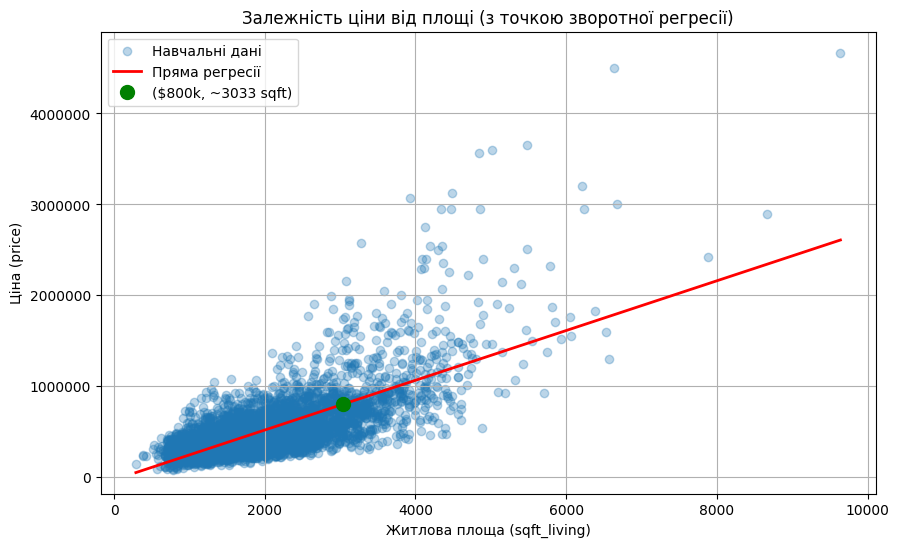

In [14]:
# Бонус — оцініть площу для будинку вартістю $800 000 та побудуйте графік
target_price = 800000
estimated_sqft = inverse_regression_predictions(target_price, sqft_intercept, sqft_slope)
print(f"Оцінна площа для будинку вартістю $800 000 становить приблизно {estimated_sqft:.0f} кв. футів.")

plt.figure(figsize=(10, 6))

plt.scatter(train_data['sqft_living'], train_data['price'], alpha=0.3, label='Навчальні дані')

x_vals = np.array([train_data['sqft_living'].min(), train_data['sqft_living'].max()])
y_vals = get_regression_predictions(x_vals, sqft_intercept, sqft_slope)
plt.plot(x_vals, y_vals, color='red', linewidth=2, label='Пряма регресії')

plt.plot(estimated_sqft, target_price, 'go', markersize=10, label=f'($800k, ~{estimated_sqft:.0f} sqft)')

plt.xlabel('Житлова площа (sqft_living)')
plt.ylabel('Ціна (price)')
plt.title('Залежність ціни від площі (з точкою зворотної регресії)')
plt.legend()
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.show()